# Deepfake Detection & Attribution con Explainability

**Multimedia Forensics — Laurea Magistrale**  ·  pipeline multi-stream (RGB + Fourier) su Colab T4.

Pipeline:
1. **Feature**: immagine → ResNet18(ImageNet) → embedding ; spettro di Fourier → ResNet18 → embedding
2. **Classificatore a cascata** sugli embedding concatenati → *detection* (real/fake); se *fake* → *attribution* tra i generatori
3. **Explainability**: Grad-CAM sui due stream + **agent VLM open** (Qwen2.5-VL) che spiega il *perché*

> `Runtime → Change runtime type → T4 GPU` prima di eseguire.

## 0. Bootstrap (Colab)

Su un runtime Colab (VM remota) i file locali non esistono: questa cella clona il
repo **pubblico**, entra in `Progetto/`, installa le dipendenze e scarica il dataset.
In locale viene saltata automaticamente.

In [1]:
# Esegui per primo. Idempotente: su Colab clona/AGGIORNA il repo, installa, scarica i dati.
# Forza sempre l'allineamento all'ultimo commit (scarta modifiche locali, es. output salvati).
import os

REPO = 'https://github.com/giuliopedicone02/MultimediaForensics.git'

def _on_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _on_colab():
    BASE = '/content'
    REPO_DIR = os.path.join(BASE, 'MultimediaForensics')
    os.chdir(BASE)
    if not os.path.isdir(REPO_DIR):
        !git clone --depth 1 {REPO}
    else:
        # allinea all'ultimo commit, scartando ogni modifica locale (output del notebook)
        !git -C {REPO_DIR} fetch --depth 1 origin main -q && git -C {REPO_DIR} reset --hard origin/main -q
    os.chdir(os.path.join(REPO_DIR, 'Progetto'))
    print('cwd:', os.getcwd())
    !git -C {REPO_DIR} log -1 --oneline
    !pip -q install -r requirements.txt
    !pip -q install transformers accelerate bitsandbytes qwen-vl-utils sentencepiece
    # dataset (gitignorato): scarica solo se manca DAVVERO.
    # NB: data/.gitkeep e' tracciato, quindi non basta "cartella non vuota":
    # controllo che ogni classe abbia immagini reali (file non nascosti).
    _classi = ['real', 'stylegan', 'stylegan3', 'sdxl']
    def _ha_dati(c):
        d = os.path.join('data', c)
        return os.path.isdir(d) and any(not f.startswith('.') for f in os.listdir(d))
    if not all(_ha_dati(c) for c in _classi):
        !python scripts/download_data.py --per-class 300
    else:
        print('dataset gia presente: download saltato.')
else:
    print('Bootstrap saltato (locale).')

Cloning into 'MultimediaForensics'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 127 (delta 1), reused 108 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 198.61 MiB | 23.92 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (151/151), done.
cwd: /content/MultimediaForensics/Progetto
8414552 (grafted, HEAD -> main, origin/main, origin/HEAD) Fix: etichette diagrammi README a capo con <br/> (no piu' testo troncato)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 65.8 MB/s eta 0:00:00:00:0100:01
[real] da bitmind/ffhq-256 -> data/real (già presenti: 0)
    300/300
[real] completato: 300 immagini.
[stylegan] da 34data/STYLEGAN -> data/stylegan (già presenti: 0)
    300/300
[stylegan] completato: 300 immagini.
[stylegan3] da 34data/stylegan3_T_FF

## 1. Setup

In [2]:
# Installazione dipendenze (su Colab torch/torchvision ci sono già).
# Decommenta alla prima esecuzione su Colab:
# !pip -q install transformers>=4.49 accelerate bitsandbytes qwen-vl-utils sentencepiece pyyaml

import torch
print('torch', torch.__version__, '| CUDA:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

torch 2.11.0+cu128 | CUDA: True
GPU: Tesla T4


In [ ]:
# Rende importabile il package `dffa` in modo robusto.
# Cerca la cartella che contiene davvero `dffa/` (utile su Colab dopo un
# riavvio del runtime: la cwd torna a /content e va ritrovato il clone).
import sys, os

def _find_project_root():
    candidates = [
        os.getcwd(),                                   # qui
        os.path.abspath('..'),                         # se siamo in notebooks/
        'MultimediaForensics/Progetto',                # clone relativo
        '/content/MultimediaForensics/Progetto',       # clone tipico su Colab
    ]
    for c in candidates:
        if os.path.isdir(os.path.join(c, 'dffa')):
            return os.path.abspath(c)
    raise SystemExit(
        "Cartella 'Progetto' non trovata: esegui prima la cella 0 (Bootstrap)."
    )

ROOT = _find_project_root()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
print('project root:', ROOT)

import dffa
print('dffa', dffa.__version__)

project root: /content/MultimediaForensics/Progetto
dffa 0.1.0


## 2. Configurazione

In [4]:
from dffa.config import Config
from dffa.utils import set_seed, get_device, ensure_dir, save_json

cfg = Config(
    data_root=os.path.join(ROOT, 'data'),
    classes=['real', 'stylegan', 'stylegan3', 'sdxl'],
    max_per_class=250,      # ~1000 immagini totali; metti None per usarle tutte
    epochs=30,               # tetto massimo
    early_stopping_patience=8,  # stop se la cascade-acc di val non migliora per 8 epoche
    batch_size=32,
)
set_seed(cfg.seed)
device = get_device(cfg.device)
results_dir = ensure_dir(os.path.join(ROOT, cfg.results_dir))
print('device:', device, '| classi:', cfg.classes)

TypeError: Config.__init__() got an unexpected keyword argument 'early_stopping_patience'

## 3. Dati

Disponi le immagini in `data/<classe>/` (es. `data/real`, `data/stylegan`, …).
Le classi assenti vengono ignorate: puoi partire anche con sole 2 classi.

In [ ]:
from dffa.data import build_splits, list_samples
from collections import Counter

all_samples = list_samples(cfg)
if not all_samples:
    raise SystemExit('Nessuna immagine trovata: popola data/<classe>/ prima di proseguire.')
counts = Counter(cfg.classes[i] for _, i in all_samples)
print('immagini per classe:', dict(counts))

splits = build_splits(cfg)
print({k: len(v) for k, v in splits.items()})

immagini per classe: {'real': 250, 'stylegan': 250, 'stylegan3': 250, 'sdxl': 250}
{'train': 696, 'val': 152, 'test': 152}


## 4. Feature extraction (ResNet18 dual-stream, con cache)

In [ ]:
from dffa.features import DualStreamExtractor
from dffa.engine import extract_embeddings

extractor = DualStreamExtractor(pretrained=True, freeze=True).to(device)

blobs = {}
for name in ['train', 'val', 'test']:
    cache = os.path.join(results_dir, f'emb_{name}.pt')
    blobs[name] = extract_embeddings(splits[name], cfg, extractor, device, cache_path=cache)
    print(name, blobs[name]['embeddings'].shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s] 


embedding:   0%|          | 0/22 [00:00<?, ?it/s]

train torch.Size([696, 1024])


embedding:   0%|          | 0/5 [00:00<?, ?it/s]

val torch.Size([152, 1024])


embedding:   0%|          | 0/5 [00:00<?, ?it/s]

test torch.Size([152, 1024])


## 5. Sanity check — immagine vs spettro di Fourier

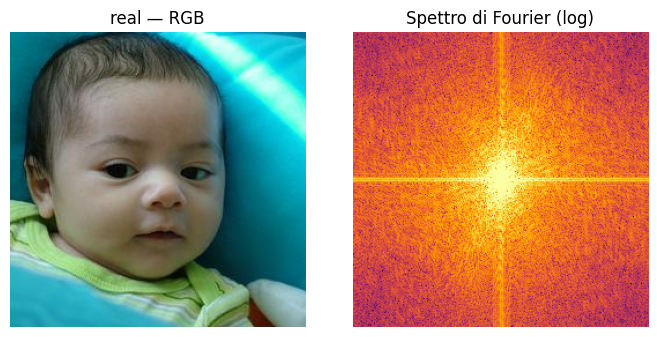

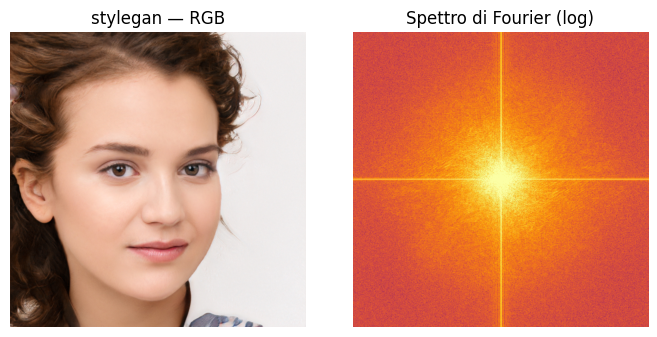

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from dffa.features.fourier import fourier_spectrum

def show_pair(path, title):
    img = Image.open(path).convert('RGB')
    spec = fourier_spectrum(img, log=True)
    fig, ax = plt.subplots(1, 2, figsize=(7, 3.4))
    ax[0].imshow(img); ax[0].set_title(f'{title} — RGB'); ax[0].axis('off')
    ax[1].imshow(spec, cmap='inferno'); ax[1].set_title('Spettro di Fourier (log)'); ax[1].axis('off')
    plt.tight_layout(); plt.show()

# un esempio reale e uno fake (se disponibili)
by_cls = {}
for p, i in all_samples:
    by_cls.setdefault(cfg.classes[i], p)
for cls in ['real', 'stylegan']:
    if cls in by_cls:
        show_pair(by_cls[cls], cls)

## 6. Training del classificatore multi-task

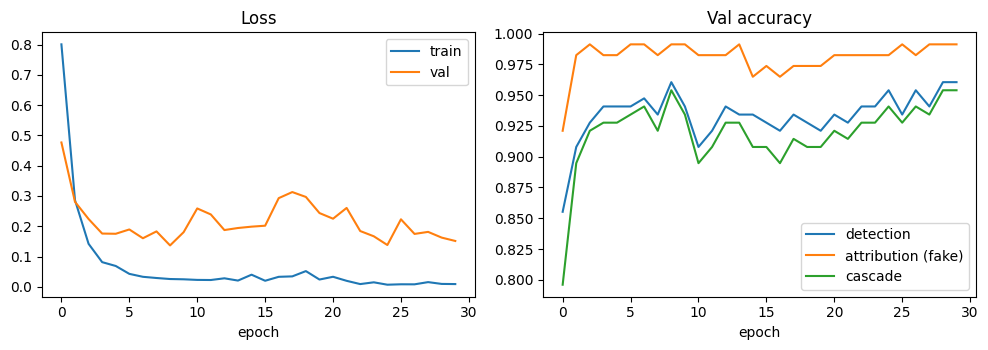

In [ ]:
from dffa.engine import train_classifier

model, history = train_classifier(blobs['train'], blobs['val'], cfg, device)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(history['train_loss'], label='train'); ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['val_det_acc'], label='detection'); ax[1].plot(history['val_attr_acc'], label='attribution (fake)')
ax[1].plot(history['val_cascade_acc'], label='cascade')
ax[1].set_title('Val accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
be = history.get('best_epoch', -1)
if be is not None and be >= 0:
    for a in ax: a.axvline(be, ls='--', color='grey', lw=1)
    ax[0].set_title(f'Loss (best/early-stop @ epoca {be})')
print(f"best epoch={history.get('best_epoch')}  stop @ epoca={history.get('stopped_epoch')}")
plt.tight_layout(); plt.show()

## 7. Valutazione sul test set

Detection acc          : 0.9803
Attribution acc (fake) : 0.9912
Cascade acc (end-to-end): 0.9737

== Detection (real vs fake, tutti i campioni) ==
              precision    recall  f1-score   support

        real       0.93      1.00      0.96        38
        fake       1.00      0.97      0.99       114

    accuracy                           0.98       152
   macro avg       0.96      0.99      0.97       152
weighted avg       0.98      0.98      0.98       152

== Attribution (SOLO fake, tra generatori) ==
              precision    recall  f1-score   support

    stylegan       0.97      1.00      0.99        38
   stylegan3       1.00      1.00      1.00        38
        sdxl       1.00      0.97      0.99        38

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



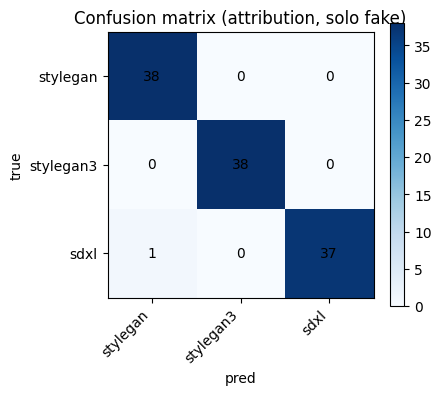

In [ ]:
from dffa.engine import evaluate, _loader_from_blob
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

test_loader = _loader_from_blob(blobs['test'], cfg, shuffle=False)
res = evaluate(model, test_loader, cfg, device)
print(f"Detection acc          : {res['detection_acc']:.4f}")
print(f"Attribution acc (fake) : {res['attribution_acc']:.4f}")
print(f"Cascade acc (end-to-end): {res['cascade_acc']:.4f}")

print('\n== Detection (real vs fake, tutti i campioni) ==')
print(classification_report(res['detection_true'], res['detection_pred'],
                            target_names=['real', 'fake'], zero_division=0))
print('== Attribution (SOLO fake, tra generatori) ==')
gens = cfg.generator_classes
present = sorted(set(res['attribution_true']) | set(res['attribution_pred']))
print(classification_report(res['attribution_true'], res['attribution_pred'],
                            labels=present, target_names=[gens[i] for i in present],
                            zero_division=0))

cm = confusion_matrix(res['attribution_true'], res['attribution_pred'], labels=present)
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(present))); ax.set_xticklabels([gens[i] for i in present], rotation=45, ha='right')
ax.set_yticks(range(len(present))); ax.set_yticklabels([gens[i] for i in present])
ax.set_xlabel('pred'); ax.set_ylabel('true'); ax.set_title('Confusion matrix (attribution, solo fake)')
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        ax.text(c, r, cm[r, c], ha='center', va='center')
plt.colorbar(im); plt.tight_layout(); plt.show()

## 7-bis. Ablation — il confound della risoluzione

Le classi hanno **risoluzioni native diverse** (real/sdxl 256, StyleGAN 1024, StyleGAN3 244).
Portandole tutte a 224 con lo stesso resize, il *fattore* di ridimensionamento resta diverso
per classe e lascia una "firma" che il modello può sfruttare al posto dei veri artefatti
generativi, gonfiando le metriche. Qui lo dimostriamo e lo neutralizziamo:

1. **RAW vs CANONICA** — nessuna uniformazione (`canonical_size=None`) contro l'uniformazione
   a monte (tutte le immagini a `canonical_size`, stessa interpolazione, *prima* di RGB e Fourier).
   Se l'accuracy crolla passando da RAW a CANONICA, il confound era reale.
2. **Ablation degli stream** — RGB-only / Fourier-only / both sui dati canonici.

In [ ]:
from dataclasses import replace
from dffa.engine import slice_stream

# A) RAW (nessuna uniformazione) vs CANONICA (il run principale 'res' usa gia' canonical_size)
cfg_raw = replace(cfg, canonical_size=None)
sp_raw = build_splits(cfg_raw)
blobs_raw = {s: extract_embeddings(sp_raw[s], cfg_raw, extractor, device,
             cache_path=os.path.join(results_dir, f'emb_raw_{s}.pt'))
             for s in ['train', 'val', 'test']}
m_raw, _ = train_classifier(blobs_raw['train'], blobs_raw['val'], cfg_raw, device)
r_raw = evaluate(m_raw, _loader_from_blob(blobs_raw['test'], cfg_raw, shuffle=False), cfg_raw, device)

print('== Confound risoluzione: RAW vs CANONICA ==')
print(f"RAW  (canonical=None)   det={r_raw['detection_acc']:.3f}  attr(fake)={r_raw['attribution_acc']:.3f}  cascade={r_raw['cascade_acc']:.3f}")
print(f"CANONICA ({cfg.canonical_size})        det={res['detection_acc']:.3f}  attr(fake)={res['attribution_acc']:.3f}  cascade={res['cascade_acc']:.3f}")

# B) ablation degli stream sui dati canonici (blobs = run principale)
print('\n== Ablation stream (dati canonici) ==')
ablation = {}
for w in ['rgb', 'fourier', 'both']:
    bs = {s: slice_stream(blobs[s], w) for s in ['train', 'val', 'test']}
    mw, _ = train_classifier(bs['train'], bs['val'], cfg, device)
    rw = evaluate(mw, _loader_from_blob(bs['test'], cfg, shuffle=False), cfg, device)
    ablation[w] = {'detection_acc': rw['detection_acc'], 'attribution_acc': rw['attribution_acc'], 'cascade_acc': rw['cascade_acc']}
    print(f"  {w:8s} det={rw['detection_acc']:.3f}  attr(fake)={rw['attribution_acc']:.3f}  cascade={rw['cascade_acc']:.3f}")

embedding:   0%|          | 0/22 [00:00<?, ?it/s]

embedding:   0%|          | 0/5 [00:00<?, ?it/s]

embedding:   0%|          | 0/5 [00:00<?, ?it/s]

== Confound risoluzione: RAW vs CANONICA ==
RAW  (canonical=None)   det=0.987  attr(fake)=1.000  cascade=0.987
CANONICA (256)        det=0.980  attr(fake)=0.991  cascade=0.974

== Ablation stream (dati canonici) ==
  rgb      det=0.961  attr(fake)=1.000  cascade=0.961
  fourier  det=0.776  attr(fake)=0.904  cascade=0.711
  both     det=0.947  attr(fake)=0.991  cascade=0.941


## 7-ter. Generalizzazione — Leave-One-Generator-Out (LOGO)

La vera domanda forense: il rilevatore riconosce come *fake* un generatore **mai
visto** in addestramento? Per ogni generatore alleniamo la detection su
`real + (altri 2 generatori)` e testiamo su `real + il generatore escluso`.

Se l'accuracy (e soprattutto il *recall* sui fake mai visti) **crolla** rispetto al
~0.97 in-distribution, il modello non ha imparato la "fakeness" generale ma la firma
specifica di ciascun dataset/sorgente: prova diretta del confound di sorgente.

In [ ]:
from dffa.engine import cross_generator_detection

logo = cross_generator_detection(blobs, cfg, device)
print('== LOGO: detection su un generatore MAI visto in training ==')
print(f"(riferimento in-distribution: detection acc = {res['detection_acc']:.3f})\n")
for g, m in logo.items():
    print(f"  held-out {g:10s}: detection_acc={m['detection_acc']:.3f}  recall_fake_mai_visto={m['unseen_fake_recall']:.3f}")
import numpy as np
print(f"\n  media detection_acc held-out: {np.mean([m['detection_acc'] for m in logo.values()]):.3f}")

== LOGO: detection su un generatore MAI visto in training ==
(riferimento in-distribution: detection acc = 0.980)

  held-out stylegan  : detection_acc=0.539  recall_fake_mai_visto=0.079
  held-out stylegan3 : detection_acc=0.618  recall_fake_mai_visto=0.289
  held-out sdxl      : detection_acc=0.487  recall_fake_mai_visto=0.000

  media detection_acc held-out: 0.548


## 7-quater. Benchmark same-source — real vs SDXL

`real` (FFHQ-256) e `sdxl` provengono dalla **stessa** base FFHQ-256 (entrambi PNG 256×256):
questa coppia **a sorgente condivisa** rimuove il confound di dataset, quindi la detection
qui è quella di cui ci si può fidare. Controlliamo inoltre che il segnale non sia un banale
confound di *colore di set*: baseline sul solo colore e **color-normalization** per-immagine.
Lettura completa nel report §5.7.

In [ ]:
# §7-quater — Benchmark SAME-SOURCE: real vs SDXL (stessa base FFHQ-256). Report §5.7.
import numpy as np, torch
from PIL import Image
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from dffa.engine import _filter_blob, slice_stream

gens = cfg.generator_classes

def pair_blobs(gi):
    return {s: _filter_blob(blobs[s], (blobs[s]['attribution'] == -1) | (blobs[s]['attribution'] == gi))
            for s in ['train', 'val', 'test']}

def det(sub):
    m, _ = train_classifier(sub['train'], sub['val'], cfg, device)
    return evaluate(m, _loader_from_blob(sub['test'], cfg, shuffle=False), cfg, device)

print('== Detection pairwise: real vs singolo generatore (test bilanciato 38+38) ==')
for gi, g in enumerate(gens):
    r = det(pair_blobs(gi))
    print(f'  real vs {g:10s}: det acc = {r["detection_acc"]:.3f}' + ('  <-- SAME-SOURCE' if g == 'sdxl' else ''))

# Dettaglio coppia pulita real vs SDXL
sub = pair_blobs(gens.index('sdxl'))
r = det(sub)
print(f'\n== real vs SDXL (same-source) ==  detection acc = {r["detection_acc"]:.3f}')
print(classification_report(r['detection_true'], r['detection_pred'],
                            target_names=['real', 'sdxl'], digits=3, zero_division=0))
print('Confusion matrix [true x pred]:\n', confusion_matrix(r['detection_true'], r['detection_pred']))
print('Ablation stream (real vs SDXL):')
for w in ['rgb', 'fourier', 'both']:
    sw = {k: slice_stream(sub[k], w) for k in ['train', 'val', 'test']}
    print(f'   {w:8s}: det acc = {det(sw)["detection_acc"]:.3f}')

# --- Controllo confound di set: baseline colore + color-normalization ---
CS, IS = cfg.canonical_size or 256, cfg.image_size
resize_tt = transforms.Compose([transforms.Resize((IS, IS)), transforms.ToTensor()])
imnet_m = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
imnet_s = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def rgb_emb(paths, colornorm):
    outs = []
    for i in range(0, len(paths), 64):
        b = []
        for p in paths[i:i+64]:
            t = resize_tt(Image.open(p).convert('RGB').resize((CS, CS), Image.BICUBIC))
            t = (t - t.mean((1, 2), keepdim=True)) / (t.std((1, 2), keepdim=True) + 1e-6) if colornorm else (t - imnet_m) / imnet_s
            b.append(t)
        with torch.no_grad():
            outs.append(extractor.rgb(torch.stack(b).to(device)).cpu())
    return torch.cat(outs).numpy()

def color_feats(paths):
    X = []
    for p in paths:
        a = np.asarray(Image.open(p).convert('RGB').resize((CS, CS)), dtype=np.float32) / 255.
        X.append(np.concatenate([a.mean((0, 1)), a.std((0, 1))]))
    return np.array(X)

def real_sdxl(split):
    P, Y = [], []
    for path, ci in splits[split]:
        c = cfg.classes[ci]
        if c == 'real': P.append(path); Y.append(0)
        elif c == 'sdxl': P.append(path); Y.append(1)
    return P, np.array(Y)

Ptr, Ytr = real_sdxl('train'); Pte, Yte = real_sdxl('test')
print('\n== Controllo confound di set (real vs SDXL) ==')
bl = LogisticRegression(max_iter=2000).fit(color_feats(Ptr), Ytr).score(color_feats(Pte), Yte)
print(f'  baseline banale (solo media+std colore): {bl:.3f}  (0.5 = caso)')
for cn, name in [(False, 'RGB normale (ImageNet)'), (True, 'RGB + color-normalization')]:
    acc = LogisticRegression(max_iter=2000).fit(rgb_emb(Ptr, cn), Ytr).score(rgb_emb(Pte, cn), Yte)
    print(f'  {name:28s}: {acc:.3f}')

== Detection pairwise: real vs singolo generatore (test bilanciato 38+38) ==
  real vs stylegan  : det acc = 0.961
  real vs stylegan3 : det acc = 0.961
  real vs sdxl      : det acc = 0.987  <-- SAME-SOURCE

== real vs SDXL (same-source) ==  detection acc = 0.987
              precision    recall  f1-score   support

        real      0.974     1.000     0.987        38
        sdxl      1.000     0.974     0.987        38

    accuracy                          0.987        76
   macro avg      0.987     0.987     0.987        76
weighted avg      0.987     0.987     0.987        76

Confusion matrix [true x pred]:
 [[38  0]
 [ 1 37]]
Ablation stream (real vs SDXL):
   rgb     : det acc = 0.987
   fourier : det acc = 0.711
   both    : det acc = 0.987

== Controllo confound di set (real vs SDXL) ==
  baseline banale (solo media+std colore): 0.763  (0.5 = caso)
  RGB normale (ImageNet)      : 0.987
  RGB + color-normalization   : 0.987


## 7-quinquies. Robustezza a post-processing (JPEG, blur, resize, rumore)

Le immagini reali "in the wild" arrivano quasi sempre **ricompresse, ridimensionate o rumorose**. Qui misuriamo quanto regge la **detection** (real vs fake) applicando quattro famiglie di degradazione crescente. Ogni degradazione è applicata alla **risoluzione canonica (256)**, così tutte le classi sono degradate in modo identico e non si reintroduce il confound di risoluzione. Il classificatore **non** viene riaddestrato: si valuta il modello del run principale su un test set degradato.

clean (canonica, nessuna degradazione): det=0.980  cascade=0.974

  JPEG quality                95: det=0.967
  JPEG quality                90: det=0.928
  JPEG quality                75: det=0.763
  JPEG quality                50: det=0.599
  JPEG quality                30: det=0.579

  Gaussian blur (px)         0.5: det=0.974
  Gaussian blur (px)         1.0: det=0.914
  Gaussian blur (px)         1.5: det=0.862
  Gaussian blur (px)         2.0: det=0.822

  Downscale factor          0.75: det=0.941
  Downscale factor           0.5: det=0.928
  Downscale factor          0.35: det=0.941
  Downscale factor          0.25: det=0.888

  Gaussian noise (sigma)       5: det=0.803
  Gaussian noise (sigma)      10: det=0.763
  Gaussian noise (sigma)      20: det=0.750
  Gaussian noise (sigma)      30: det=0.750



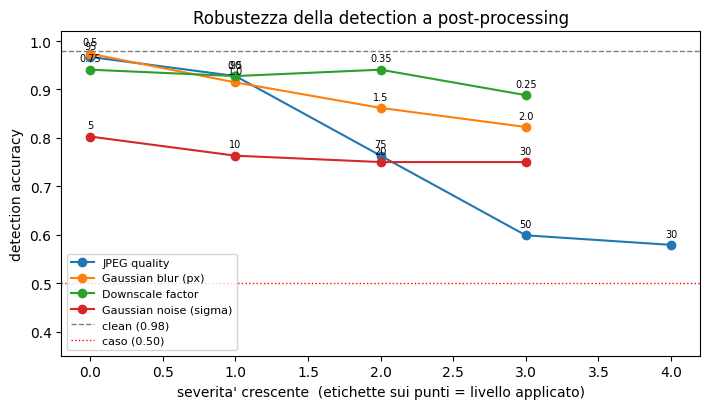

salvata report/figures/robustness.png


In [ ]:
# §7-quinquies — Robustezza della detection a degradazioni realistiche. Report §5.8.
import io
import numpy as np, torch
from PIL import Image, ImageFilter
from torchvision import transforms
from dffa.features.fourier import fourier_spectrum_tensor
from dffa.engine import evaluate, _loader_from_blob

CS, IS = cfg.canonical_size or 256, cfg.image_size
_mean, _std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
_rgb_tf = transforms.Compose([transforms.Resize((IS, IS)),
                              transforms.ToTensor(), transforms.Normalize(_mean, _std)])

# --- degradazioni: PIL 256x256 -> PIL 256x256 ---
def deg_jpeg(img, q):
    buf = io.BytesIO(); img.save(buf, format="JPEG", quality=int(q)); buf.seek(0)
    return Image.open(buf).convert("RGB")
def deg_blur(img, r):
    return img.filter(ImageFilter.GaussianBlur(radius=float(r)))
def deg_scale(img, f):
    s = max(1, int(round(CS * f)))
    return img.resize((s, s), Image.BICUBIC).resize((CS, CS), Image.BICUBIC)
def deg_noise(img, sigma):
    a = np.asarray(img, dtype=np.float32)
    a = a + np.random.RandomState(cfg.seed).normal(0, float(sigma), a.shape)
    return Image.fromarray(np.clip(a, 0, 255).astype("uint8"))

@torch.no_grad()
def eval_degraded(degrade):
    """Ri-estrae gli embedding del test applicando `degrade` alla base canonica, poi valuta."""
    samples = splits["test"]
    embs, det, attr = [], [], []
    for i in range(0, len(samples), cfg.batch_size):
        rgb_b, fft_b = [], []
        for path, ci in samples[i:i + cfg.batch_size]:
            base = degrade(Image.open(path).convert("RGB").resize((CS, CS), Image.BICUBIC))
            rgb_b.append(_rgb_tf(base))
            fft_b.append(fourier_spectrum_tensor(base, size=IS, log=cfg.fourier_log,
                         robust=cfg.fourier_robust, clip_pct=cfg.fourier_clip_pct))
            det.append(cfg.detection_label(ci)); attr.append(cfg.attribution_label(ci))
        embs.append(extractor(torch.stack(rgb_b).to(device), torch.stack(fft_b).to(device)).cpu())
    blob = {"embeddings": torch.cat(embs), "detection": torch.tensor(det).long(),
            "attribution": torch.tensor(attr).long(), "n": len(samples)}
    return evaluate(model, _loader_from_blob(blob, cfg, shuffle=False), cfg, device)

# baseline "clean" ATTRAVERSO la stessa pipeline (identity), per un confronto equo
clean = eval_degraded(lambda im: im)
print(f'clean (canonica, nessuna degradazione): det={clean["detection_acc"]:.3f}  cascade={clean["cascade_acc"]:.3f}\n')

# ogni lista e' gia' ordinata per SEVERITA' CRESCENTE (sx -> dx = peggio)
families = {
    "JPEG quality":           [95, 90, 75, 50, 30],
    "Gaussian blur (px)":     [0.5, 1.0, 1.5, 2.0],
    "Downscale factor":       [0.75, 0.5, 0.35, 0.25],
    "Gaussian noise (sigma)": [5, 10, 20, 30],
}
fns = {"JPEG quality": deg_jpeg, "Gaussian blur (px)": deg_blur,
       "Downscale factor": deg_scale, "Gaussian noise (sigma)": deg_noise}
robustness = {}
for fam, levels in families.items():
    accs = []
    for lv in levels:
        r = eval_degraded(lambda im, _f=fns[fam], _l=lv: _f(im, _l))
        accs.append(r["detection_acc"])
        print(f"  {fam:24s} {str(lv):>5s}: det={r['detection_acc']:.3f}")
    robustness[fam] = {"levels": levels, "detection_acc": accs}
    print()

# --- figura: una curva per famiglia (x = severita' crescente per indice) ---
import matplotlib.pyplot as plt
FIG = ensure_dir(os.path.join(ROOT, "report", "figures"))
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for fam, d in robustness.items():
    xs = range(len(d["levels"]))
    ax.plot(list(xs), d["detection_acc"], marker="o", label=fam)
    for x, lv, a in zip(xs, d["levels"], d["detection_acc"]):
        ax.annotate(str(lv), (x, a), fontsize=7, textcoords="offset points", xytext=(0, 6), ha="center")
ax.axhline(clean["detection_acc"], ls="--", c="gray", lw=1, label=f'clean ({clean["detection_acc"]:.2f})')
ax.axhline(0.5, ls=":", c="red", lw=1, label="caso (0.50)")
ax.set_xlabel("severita' crescente  (etichette sui punti = livello applicato)")
ax.set_ylabel("detection accuracy"); ax.set_ylim(0.35, 1.02)
ax.set_title("Robustezza della detection a post-processing")
ax.legend(fontsize=8, loc="lower left"); fig.tight_layout()
fig.savefig(os.path.join(FIG, "robustness.png"), dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
print("salvata report/figures/robustness.png")


## 8. Grad-CAM — dove guarda la rete (RGB e Fourier)

detection: fake | attribution: stylegan


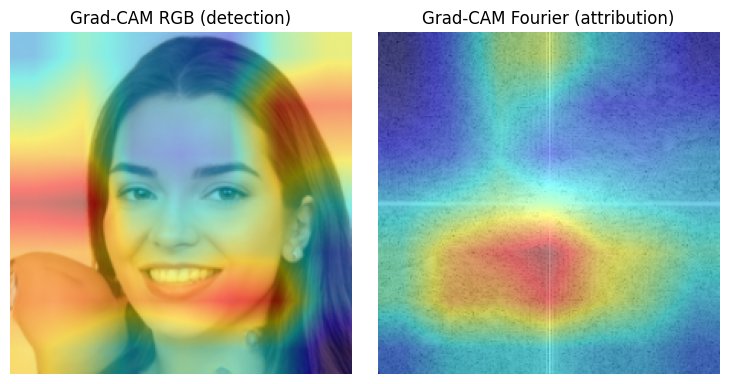

In [ ]:
from dffa.data import ForensicsDataset
from dffa.explain import GradCAM, overlay_cam
from dffa.models import cascade_predict

# scelgo un campione FAKE dal test, così l'attribution è applicabile
sample_path, sample_attr = next((s for s in splits['test'] if cfg.classes[s[1]] != 'real'), splits['test'][0])
ds_one = ForensicsDataset([(sample_path, sample_attr)], cfg)
item = ds_one[0]
rgb = item['rgb'].unsqueeze(0).to(device)
fft = item['fourier'].unsqueeze(0).to(device)

# embedding + decisione a cascata (detection -> se fake -> attribution)
with torch.no_grad():
    emb = extractor(rgb, fft)
    pred, decisions = cascade_predict(model, emb, cfg.generator_classes)
dec = decisions[0]
det_cls = int(pred['detection_pred'][0]); gen_cls = int(pred['attribution_pred'][0])
print('detection:', dec['detection'], '| attribution:', dec['attribution'])

# Grad-CAM sullo stream RGB rispetto al logit di detection predetto
cam_rgb = GradCAM(extractor.rgb, extractor.rgb.target_layer)
heat_rgb = cam_rgb(rgb, score_fn=lambda f: model(torch.cat([f, extractor.fourier(fft)],1)).detection_logits[:, det_cls])
cam_rgb.remove()

# Grad-CAM sullo stream Fourier rispetto al generatore predetto (attribution)
cam_fft = GradCAM(extractor.fourier, extractor.fourier.target_layer)
heat_fft = cam_fft(fft, score_fn=lambda f: model(torch.cat([extractor.rgb(rgb), f],1)).attribution_logits[:, gen_cls])
cam_fft.remove()

ov_rgb = overlay_cam(item['rgb'], heat_rgb)
ov_fft = overlay_cam(item['fourier'], heat_fft)
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.8))
ax[0].imshow(ov_rgb); ax[0].set_title('Grad-CAM RGB (detection)'); ax[0].axis('off')
ax[1].imshow(ov_fft); ax[1].set_title('Grad-CAM Fourier (attribution)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

## 9. Agent VLM — spiegazione in linguaggio naturale

L'agent open (Qwen2.5-VL, 4-bit su T4) osserva RGB + Fourier + Grad-CAM e le
probabilità del classificatore, e spiega *perché* real/fake e *perché* quel
generatore. Senza GPU/modello ricade su una spiegazione template-based.

In [ ]:
from dffa.explain import VLMExplainer, build_evidence
from dffa.explain.gradcam import _jet
from PIL import Image as PILImage

explainer = VLMExplainer(cfg.vlm_model_id, load_in_4bit=cfg.vlm_load_in_4bit,
                         max_new_tokens=cfg.vlm_max_new_tokens, device=str(device))
loaded = explainer.load() if cfg.vlm_enabled else False
print('VLM caricato:', loaded)

# evidenze numeriche per il campione di Grad-CAM
evidence = build_evidence(
    detection_prob=pred['detection_prob'][0].cpu().numpy(),
    attribution_prob=pred['attribution_prob'][0].cpu().numpy(),
    generator_classes=cfg.generator_classes,
    cam_stats={'mean': float(heat_rgb.mean()), 'max': float(heat_rgb.max())},
)

images = {
    'rgb': PILImage.open(sample_path).convert('RGB'),
    'fourier': PILImage.fromarray((_jet(fourier_spectrum(PILImage.open(sample_path).convert('RGB')))*255).astype('uint8')),
    'gradcam': PILImage.fromarray(ov_rgb),
}
exp = explainer.explain(images, evidence)
print(f'[fonte: {exp.source}]\n')
print(exp.text)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

VLM caricato: True


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[fonte: vlm]

L'immagine originale mostra una persona con capelli lunghi e una maglietta gialla. L'immagine è ben risolta e ha una colorazione naturale. Il spettro di Fourier mostra una distribuzione di frequenze simmetrica con picchi principali, indicando una struttura complessiva. La mappa Grad-CAM evidenzia le zone più importanti per il classificatore, concentrandosi sul viso e sulle orecchie della persona. Le predizioni del classificatore indicano che l'immagine è falsa con una certificazione di 99,95% e una probabilità reale di 0,0005. L'attribuzione al generatore è stilegan con una certificazione di 99,99%. 

Le evidenze visive realmente osservabili includono la presenza di una persona con capelli lunghi, una maglietta gialla e una posizione del braccio. Non sono presenti griglie periodiche o incoerenze di texture che potrebbero suggerire artefatti. Tuttavia, non è possibile vedere direttamente artefatti come griglie periodiche o incoerenze di texture. 

Il modello potrebbe basar

## 10. Salvataggio dei risultati

In [ ]:
summary = {
    'config': cfg.__dict__,
    'counts': dict(counts),
    'splits': {k: len(v) for k, v in splits.items()},
    'detection_acc': res['detection_acc'],
    'attribution_acc': res['attribution_acc'],
    'cascade_acc': res['cascade_acc'],
    # ablation (vedi sezione 7-bis): confound della risoluzione + contributo degli stream
    'ablation_raw': {'detection_acc': r_raw['detection_acc'],
                     'attribution_acc': r_raw['attribution_acc'],
                     'cascade_acc': r_raw['cascade_acc']},
    'ablation_streams': ablation,
    'logo_cross_generator': logo,
    # robustezza a post-processing (vedi 7-quinquies)
    'robustness_clean_det_acc': clean['detection_acc'],
    'robustness': robustness,
    'example_explanation': {'path': sample_path, 'detection': dec['detection'],
                            'attribution': dec['attribution'], 'source': exp.source, 'text': exp.text},
}
save_json(summary, os.path.join(results_dir, 'summary.json'))
torch.save(model.state_dict(), os.path.join(results_dir, 'classifier.pt'))
print('Salvato in', results_dir)

Salvato in /content/MultimediaForensics/Progetto/results


## 11. Esportazione figure per il report

Salva in `report/figures/` i PNG da inserire nella relazione: curve di training,
matrice di confusione dell'attribution, Grad-CAM e pannello qualitativo dell'esempio
spiegato dal VLM. Scaricali dal pannello file di Colab.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
FIG = ensure_dir(os.path.join(ROOT, 'report', 'figures'))  # versionate nel repo

# 1) curve di training
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].plot(history['train_loss'], label='train'); ax[0].plot(history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(history['val_det_acc'], label='detection')
ax[1].plot(history['val_attr_acc'], label='attribution (fake)')
ax[1].plot(history['val_cascade_acc'], label='cascade')
ax[1].set_title('Val accuracy'); ax[1].set_xlabel('epoch'); ax[1].legend()
be = history.get('best_epoch', -1)
if be is not None and be >= 0:
    for a in ax: a.axvline(be, ls='--', color='grey', lw=1)
    ax[0].set_title(f'Loss (best/early-stop @ epoca {be})')
fig.tight_layout(); fig.savefig(os.path.join(FIG, 'training_curves.png'), dpi=150, bbox_inches='tight'); plt.close(fig)

# 2) confusion matrix attribution (solo fake)
gens = cfg.generator_classes
present = sorted(set(res['attribution_true']) | set(res['attribution_pred']))
cm = confusion_matrix(res['attribution_true'], res['attribution_pred'], labels=present)
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(present))); ax.set_xticklabels([gens[i] for i in present], rotation=45, ha='right')
ax.set_yticks(range(len(present))); ax.set_yticklabels([gens[i] for i in present])
ax.set_xlabel('pred'); ax.set_ylabel('true'); ax.set_title('Attribution (solo fake)')
for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):
        ax.text(c, r, cm[r, c], ha='center', va='center')
fig.colorbar(im); fig.tight_layout(); fig.savefig(os.path.join(FIG, 'cm_attribution.png'), dpi=150, bbox_inches='tight'); plt.close(fig)

# 3) Grad-CAM RGB + Fourier
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.8))
ax[0].imshow(ov_rgb); ax[0].set_title('Grad-CAM RGB (detection)'); ax[0].axis('off')
ax[1].imshow(ov_fft); ax[1].set_title('Grad-CAM Fourier (attribution)'); ax[1].axis('off')
fig.tight_layout(); fig.savefig(os.path.join(FIG, 'gradcam.png'), dpi=150, bbox_inches='tight'); plt.close(fig)

# 4) pannello qualitativo (RGB | Fourier | Grad-CAM) dell'esempio spiegato dal VLM
fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.6))
for a, (k, t) in zip(ax, [('rgb', 'RGB'), ('fourier', 'Spettro Fourier'), ('gradcam', 'Grad-CAM')]):
    a.imshow(images[k]); a.set_title(t); a.axis('off')
fig.suptitle(f"Esempio: detection={dec['detection']}  attribution={dec['attribution']}  [{exp.source}]")
fig.tight_layout(); fig.savefig(os.path.join(FIG, 'example_panel.png'), dpi=150, bbox_inches='tight'); plt.close(fig)

print('Figure salvate in', FIG)
for f in sorted(os.listdir(FIG)):
    print(' -', f)

Figure salvate in /content/MultimediaForensics/Progetto/report/figures
 - cm_attribution.png
 - example_panel.png
 - gradcam.png
 - misclassified_example.png
 - real_example.png
 - robustness.png
 - training_curves.png


## 12. Esempi per il report (§6) — REAL corretto e caso al limite

Rigenera in modo **riproducibile** (seed fisso ⇒ split deterministico) le figure di §6.
Il primo esempio è un'immagine *reale* classificata correttamente. Il secondo è il
**caso più critico** della detection: un **falso positivo** (reale predetta *fake*) se
presente nel run; per via della **varianza tra run** (non-determinismo cuDNN/GPU) i falsi
positivi possono non esserci, e allora si ripiega sul *real più vicino alla soglia*
(probabilità di *real* più bassa). Per ciascuno: pannello `RGB | spettro | Grad-CAM` in
`report/figures/` e spiegazione del VLM (fedele, niente template).

REAL corretto : 00044.png


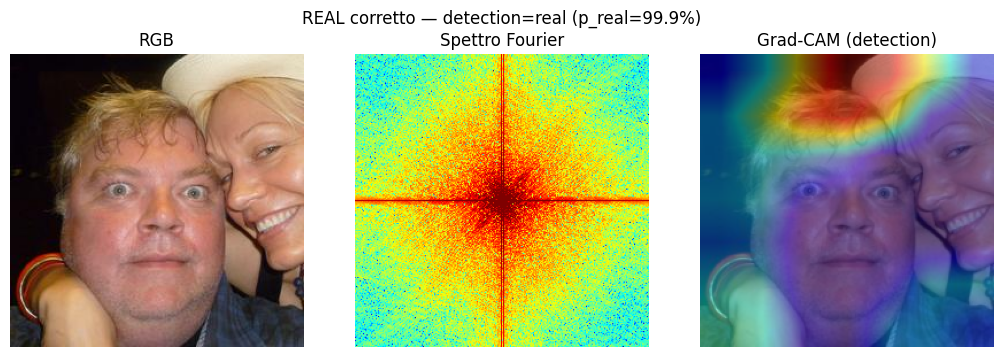

Nessun falso positivo in questo run; ripiego sul real piu' incerto (00123.png, p_real=67.0%).


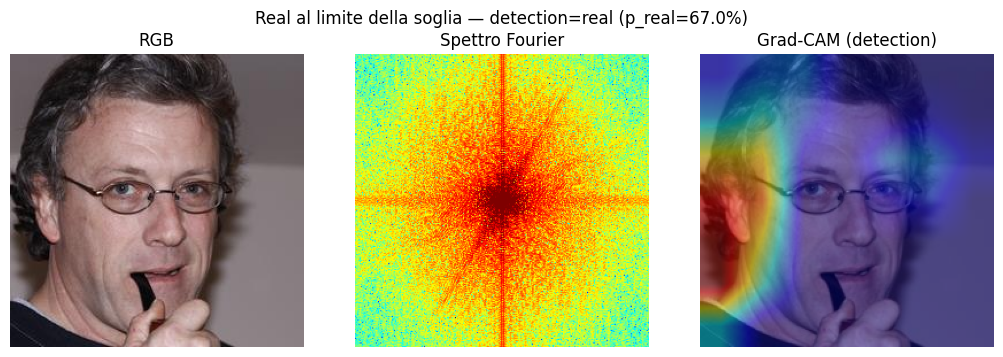

In [ ]:
# §12 — pannelli RGB | spettro Fourier | Grad-CAM per i due esempi di §6.
from dffa.data import ForensicsDataset
from dffa.explain import GradCAM, overlay_cam, build_evidence
from dffa.explain.gradcam import _jet
from dffa.models import cascade_predict
from PIL import Image as PILImage

def _predict(sample_path, attr_label):
    it = ForensicsDataset([(sample_path, attr_label)], cfg)[0]
    rgb = it["rgb"].unsqueeze(0).to(device); fft = it["fourier"].unsqueeze(0).to(device)
    with torch.no_grad():
        pred, decisions = cascade_predict(model, extractor(rgb, fft), cfg.generator_classes)
    return it, rgb, fft, pred, decisions[0]

def _panel(sample_path, attr_label, out_name, prefix):
    """Salva il pannello e ritorna (pred, dec, images, heat) per la spiegazione VLM."""
    it, rgb, fft, pred, dec = _predict(sample_path, attr_label)
    det_cls = int(pred["detection_pred"][0])
    cam = GradCAM(extractor.rgb, extractor.rgb.target_layer)
    heat = cam(rgb, score_fn=lambda f: model(torch.cat([f, extractor.fourier(fft)], 1)).detection_logits[:, det_cls])
    cam.remove()
    ov = overlay_cam(it["rgb"], heat)
    pil = PILImage.open(sample_path).convert("RGB")
    images = {"rgb": pil,
              "fourier": PILImage.fromarray((_jet(fourier_spectrum(pil)) * 255).astype("uint8")),
              "gradcam": PILImage.fromarray(ov)}
    fig, ax = plt.subplots(1, 3, figsize=(10.5, 3.6))
    for a, (k, t) in zip(ax, [("rgb", "RGB"), ("fourier", "Spettro Fourier"), ("gradcam", "Grad-CAM (detection)")]):
        a.imshow(images[k]); a.set_title(t); a.axis("off")
    p_real = float(pred["detection_prob"][0][0])
    extra = "" if dec["detection"] == "real" else f"  attribution={dec['attribution']}"
    fig.suptitle(f"{prefix} — detection={dec['detection']} (p_real={p_real:.1%}){extra}")
    fig.tight_layout(); fig.savefig(os.path.join(FIG, out_name), dpi=150, bbox_inches="tight"); plt.show(); plt.close(fig)
    return pred, dec, images, heat

# scorro i REAL del test (ordine deterministico): 1o corretto, 1o falso positivo,
# e tengo traccia del real piu' incerto (p_real minima) come fallback.
real_pick = fp_pick = None
worst = None  # (p_real, sample_path, attr_label)
for sp, al in splits["test"]:
    if cfg.classes[al] != "real":
        continue
    _, _, _, pred, dec = _predict(sp, al)
    p_real = float(pred["detection_prob"][0][0])
    if worst is None or p_real < worst[0]:
        worst = (p_real, sp, al)
    if dec["detection"] == "real" and real_pick is None:
        real_pick = (sp, al)
    elif dec["detection"] == "fake" and fp_pick is None:
        fp_pick = (sp, al)

print("REAL corretto :", os.path.basename(real_pick[0]) if real_pick else "nessuno")
real_ctx = _panel(*real_pick, "real_example.png", "REAL corretto") if real_pick else None

if fp_pick:
    print("Falso positivo:", os.path.basename(fp_pick[0]))
    err_ctx = _panel(*fp_pick, "misclassified_example.png", "Falso positivo (real->fake)")
elif worst:
    print(f"Nessun falso positivo in questo run; ripiego sul real piu' incerto "
          f"({os.path.basename(worst[1])}, p_real={worst[0]:.1%}).")
    err_ctx = _panel(worst[1], worst[2], "misclassified_example.png", "Real al limite della soglia")
else:
    err_ctx = None


In [ ]:
# §12 — spiegazioni VLM (fedeli) per i due esempi, come citate nel report §6.
# Riusa `explainer` caricato in §9; se il VLM non e' attivo, ricade sul template.
def _explain(ctx, label):
    pred, dec, images, heat = ctx
    ev = build_evidence(
        detection_prob=pred["detection_prob"][0].cpu().numpy(),
        attribution_prob=pred["attribution_prob"][0].cpu().numpy(),
        generator_classes=cfg.generator_classes,
        cam_stats={"mean": float(heat.mean()), "max": float(heat.max())},
    )
    e = explainer.explain(images, ev)
    print(f"=== {label} | detection={dec['detection']} | fonte: {e.source} ===\n{e.text}\n")

if real_ctx: _explain(real_ctx, "Esempio REAL")
if err_ctx:  _explain(err_ctx, "Caso al limite / falso positivo")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


=== Esempio REAL | detection=real | fonte: vlm ===
L'immagine originale mostra una coppia in posizione abbracciata. Il spettro di Fourier non evidenzia particolari artefatti o incoerenze, ma la mappa Grad-CAM mostra una regione centrale con un'intensità elevata, che potrebbe indicare un possibile artefatto o un elemento di interesse per il classificatore. Tuttavia, non sono presenti griglie periodiche o altre strutture che potrebbero essere considerate come artefatti. La predizione del classificatore è stata classificata come "real" con una certificazione molto alta (0.999), con una probabilità di falsa positività molto bassa (0.001). Questo suggerisce che l'immagine sia verosimilmente reale, ma non esclude completamente la possibilità di artefatti invisibili o di indici non visibili.

=== Caso al limite / falso positivo | detection=real | fonte: vlm ===
L'immagine originale mostra un soggetto con occhiali e un gesto pensante. Il spettro di Fourier non evidenzia particolari artefatti o